# Credit Risk Scorecard: A Real `sklearn.Pipeline` with LightGBM
### Cleaning → Imputation → Feature Engineering → LightGBM Modeling → Explainability

This notebook builds an end-to-end credit risk scorecard on a 60,000-loan dataset with
43 raw features (28 bureau/application-style attributes matching the public **Lending Club**
schema, plus 15 synthetic cash-flow / alternative-data attributes in the style of
Plaid type bank-transaction data).

**The core business question**, mirroring real production work: *does adding cash-flow
data to a traditional bureau-only scorecard produce a meaningful, statistically validated
improvement in default prediction?*

We answer it with a proper **champion/challenger framework** — and critically, both models
are built as genuine **`sklearn.pipeline.Pipeline`** objects, not loose sequential code. Feature
engineering, imputation, and categorical encoding are all pipeline 

> **Data note:** Bureau/application features are synthetically generated to match the real,
> publicly available Lending Club loan dataset schema and statistical relationships
> ([Kaggle: wordsforthewise/lending-club](https://www.kaggle.com/datasets/wordsforthewise/lending-club)).
> Cash-flow features (prefixed `cf_`) are fully synthetic — no public dataset contains
> real bank-transaction-level data, since that is proprietary, sensitive financial
> information. This is disclosed transparently in the project README.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 1. Load data and initial inspection

In [2]:
df = pd.read_csv("../data/loan_data.csv", parse_dates=["issue_d"])
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 60,000 rows x 43 columns


,loan_id,issue_d,loan_amnt,term,int_rate,installment,grade,purpose,home_ownership,addr_state,annual_inc,emp_length,fico_range_low,fico_range_high,dti,inq_last_6mths,open_acc,total_acc,mort_acc,pub_rec,revol_bal,revol_util,mths_since_earliest_cr_line,delinq_2yrs,pct_tl_nvr_dlq,pay_frequency,cf_avg_checking_balance,cf_nsf_count_6mo,cf_overdraft_count_6mo,cf_avg_daily_balance_volatility,cf_days_since_last_paycheck,cf_monthly_income_consistency,cf_num_income_deposits_90d,cf_essential_spend_ratio,cf_discretionary_spend_ratio,cf_savings_rate,cf_num_bnpl_accounts,cf_existing_loan_payment_ratio,cf_account_tenure_days,cf_negative_balance_days_90d,cf_income_source_count,first_payment_default,charged_off
0,1,2019-07-01,4300.0,36,16.19,151.58,D,credit_card,RENT,NY,47900.0,8 years,645,649,29.89,0,10,19,1.0,0,3330.0,27.6,185.0,0,99.6,biweekly,209.26,3,1,0.489,14,0.782,4,0.526,0.377,0.075,0,0.160,822,4,1,0,0
1,2,2023-08-01,7600.0,60,15.43,182.52,D,debt_consolidation,MORTGAGE,TX,56800.0,8 years,574,578,2.84,1,13,23,2.0,0,6880.0,44.0,250.0,0,100.0,monthly,933.48,2,0,0.510,10,0.849,7,0.419,0.502,0.085,0,0.129,526,4,1,0,0
2,3,2022-12-01,7000.0,60,12.48,157.41,C,debt_consolidation,MORTGAGE,MI,58200.0,8 years,677,681,18.10,2,11,23,0.0,0,3770.0,60.3,12.0,0,100.0,biweekly,2848.65,0,0,0.127,12,0.874,9,0.612,0.354,0.140,0,0.209,313,0,1,0,0
3,4,2021-08-01,8400.0,36,7.57,261.56,B,debt_consolidation,RENT,NC,23800.0,< 1 year,759,763,34.23,0,12,20,2.0,0,2590.0,28.7,312.0,2,100.0,biweekly,1189.82,1,0,0.500,17,0.962,8,0.675,0.232,0.020,0,0.267,530,10,1,0,1
4,5,2021-08-01,14300.0,36,17.86,515.98,E,small_business,RENT,FL,42900.0,6 years,581,585,25.29,2,16,25,2.0,0,6150.0,40.3,311.0,0,100.0,weekly,932.42,0,0,0.493,14,0.910,11,0.543,0.418,0.061,1,0.317,631,5,1,1,1


In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print("Columns with missing values:")
missing_summary

Columns with missing values:


,missing_count,missing_pct
cf_avg_daily_balance_volatility,3650,6.08
mort_acc,3027,5.04
emp_length,2400,4.00
pct_tl_nvr_dlq,2346,3.91
mths_since_earliest_cr_line,1889,3.15
revol_util,1118,1.86


In [4]:
print(f"Charge-off rate: {df['charged_off'].mean():.2%}")
print(f"First payment default rate: {df['first_payment_default'].mean():.2%}")

Charge-off rate: 21.69%
First payment default rate: 2.80%


## 2. Pre-split preparation

A few derived fields need to exist before we can even define the feature set: parsing the
messy `emp_length` string field, and computing the FICO midpoint from the real LC
`fico_range_low`/`fico_range_high` fields.

In [5]:
def parse_emp_length(val):
    if pd.isna(val):
        return np.nan
    if "< 1" in val:
        return 0
    if "10+" in val:
        return 10
    return int(val.split()[0])

df["emp_length_years"] = df["emp_length"].apply(parse_emp_length)

df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
loan_id,60000.0,NaN,NaN,NaN,30000.5,1.0,15000.75,30000.5,45000.25,60000.0,17320.652413
issue_d,60000,NaN,NaN,NaN,2021-12-15 09:31:33.600000,2019-01-01 00:00:00,2020-06-01 00:00:00,2022-01-01 00:00:00,2023-06-01 00:00:00,2024-12-01 00:00:00,NaN
loan_amnt,60000.0,NaN,NaN,NaN,13878.383333,1200.0,8300.0,12000.0,17400.0,40000.0,7739.837647
term,60000.0,NaN,NaN,NaN,44.3708,36.0,36.0,36.0,60.0,60.0,11.438142
int_rate,60000.0,NaN,NaN,NaN,11.823669,5.3,9.12,11.75,14.3625,27.55,3.724654
installment,60000.0,NaN,NaN,NaN,407.250383,24.63,233.23,346.91,515.2,1599.93,243.590136
grade,60000,6,C,19408,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,60000,8,debt_consolidation,27088,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_ownership,60000,4,MORTGAGE,27014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
addr_state,60000,10,FL,6116,NaN,NaN,NaN,NaN,NaN,NaN,NaN


count    6.000000e+04
mean     6.259769e+04
std      7.279298e+04
min      1.500000e+04
25%      3.870000e+04
50%      5.410000e+04
75%      7.590000e+04
max      5.325000e+06
Name: annual_inc, dtype: float64


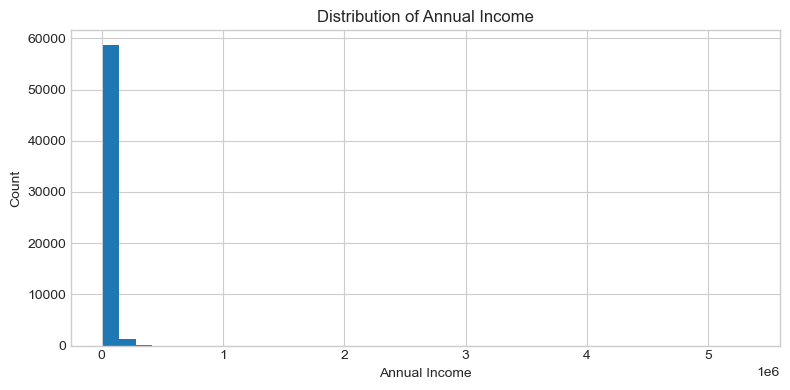

In [ ]:
# Looks like the annual income column has some outliers, let's check the distribution and summary statistics
print(df["annual_inc"].describe())

fig, ax = plt.subplots(figsize=(8, 4))
df["annual_inc"].hist(bins=40, ax=ax)
ax.set_title("Distribution of Annual Income")
ax.set_xlabel("Annual Income")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [8]:
# Outlier capping on annual_inc (a handful of obvious data-entry errors)
q99 = df["annual_inc"].quantile(0.99)
n_capped = (df["annual_inc"] > q99).sum()
df["annual_inc"] = df["annual_inc"].clip(upper=q99)
print(f"Capped {n_capped} extreme annual_inc values at 99th percentile (${q99:,.0f})")

Capped 600 extreme annual_inc values at 99th percentile ($174,201)


count     60000.000000
mean      61041.288333
std       31168.237499
min       15000.000000
25%       38700.000000
50%       54100.000000
75%       75900.000000
max      174201.000000
Name: annual_inc, dtype: float64


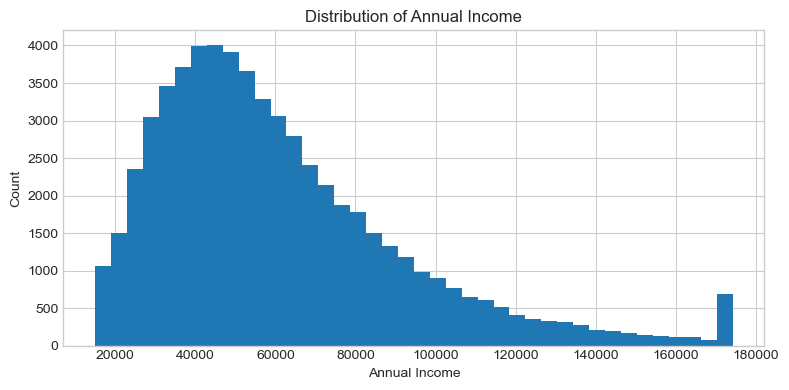

In [11]:
# Let's check again the income distribution after capping the outliers
print(df["annual_inc"].describe())

fig, ax = plt.subplots(figsize=(8, 4))
df["annual_inc"].hist(bins=40, ax=ax)
ax.set_title("Distribution of Annual Income")
ax.set_xlabel("Annual Income")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Let's also check the distribution of FICO scores
print(df["fico_mid"].describe())

fig, ax = plt.subplots(figsize=(8, 4))
df["fico_mid"].hist(bins=40, ax=ax)
ax.set_title("Distribution of FICO Midpoint")
ax.set_xlabel("FICO Score")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Train / test split

We split **before** building the pipeline so that everything downstream — imputation
statistics, encoder categories, feature scaling if any were used — is fit only on the
training set and applied unchanged to test, avoiding leakage.

In [12]:
TARGET = "charged_off"

drop_cols = [
    "loan_id", "issue_d", "fico_range_low", "fico_range_high", "emp_length",
    "first_payment_default", "charged_off",
    "grade",  # dropped: LC assigns grade using a model AFTER risk is assessed - using it
              # as a feature would leak the outcome we're trying to predict
]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Raw feature count: {len(feature_cols)}")

Train: 45,000 | Test: 15,000
Raw feature count: 37


## 4. Define the pipeline components

### 4a. A custom `FeatureEngineer` transformer

This is the key piece that makes this a genuine pipeline rather than ad-hoc script code. This eliminates a common
production bug: feature logic silently drifting between training code and serving code.

In [14]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Adds ratio/interaction features on top of the raw input columns.

    Implemented as a proper sklearn transformer (fit/transform) so it can live
    inside a Pipeline. The transform is stateless (no parameters learned from
    training data), but living inside the Pipeline still matters: it guarantees
    this exact logic is what runs at inference time on brand-new applications,
    with zero risk of train/serve skew.
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["installment_to_income"] = X["installment"] * 12 / (X["annual_inc"] + 1)
        X["loan_to_income"] = X["loan_amnt"] / (X["annual_inc"] + 1)
        X["revol_bal_to_income"] = X["revol_bal"] / (X["annual_inc"] + 1)
        X["credit_file_depth"] = X["total_acc"] / (X["mths_since_earliest_cr_line"] / 12 + 1)
        X["high_util_flag"] = (X["revol_util"] > 80).astype(int)
        X["pay_freq_monthly_flag"] = (X["pay_frequency"] == "monthly").astype(int)
        if "cf_essential_spend_ratio" in X.columns:
            X["cf_net_cash_flow_margin"] = (
                1 - X["cf_essential_spend_ratio"] - X["cf_discretionary_spend_ratio"]
            )
            X["cf_balance_to_income_ratio"] = X["cf_avg_checking_balance"] * 12 / (X["annual_inc"] + 1)
            X["cf_distress_score"] = (
                X["cf_nsf_count_6mo"] + X["cf_overdraft_count_6mo"]
                + X["cf_negative_balance_days_90d"] / 10
            )
        return X

### 4b. A reusable pipeline-builder function

`build_credit_risk_pipeline()` assembles the full pipeline: `FeatureEngineer` →
`ColumnTransformer` (median imputation for numeric columns, explicit `"Missing"` category
+ ordinal encoding for categoricals) → `LGBMClassifier`. We call this function twice — once
for the bureau-only **champion** feature set, once for the bureau + cash-flow **challenger**
feature set — so both models are genuine, independently-fittable `Pipeline` objects built
from the same reusable construction logic.

In [16]:
def build_credit_risk_pipeline(numeric_cols, categorical_cols, model_params):
    """Builds the full preprocessing + modeling pipeline for credit risk scoring.

    Step order: feature engineering runs FIRST on the raw (unimputed) columns -
    the ratio features naturally inherit NaNs where their numerator/denominator
    inputs are missing - then the ColumnTransformer imputes everything and
    encodes categoricals, and finally LightGBM is fit on the processed matrix.
    """
    engineered_numeric = [
        "installment_to_income", "loan_to_income", "revol_bal_to_income",
        "credit_file_depth", "high_util_flag", "pay_freq_monthly_flag",
    ]
    if any(columns.startswith("cf_") for columns in numeric_cols):
        engineered_numeric += [
            "cf_net_cash_flow_margin", "cf_balance_to_income_ratio", "cf_distress_score"
        ]

    preprocessing = ColumnTransformer(transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_cols + engineered_numeric),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), categorical_cols),
    ])

    return Pipeline(steps=[
        ("feature_engineering", FeatureEngineer()),
        ("preprocessing", preprocessing),
        ("model", lgb.LGBMClassifier(**model_params)),
    ])

## 5. Champion / Challenger: two independently-fit pipelines

**Champion** — bureau and application attributes only (the traditional underwriting model)
**Challenger** — champion features **plus** the 15 cash-flow (`cf_`) attributes

Each is its own complete `Pipeline` — fit, predict, and inspect independently. This is the
exact framework used in production to decide whether a new data source justifies the cost
and complexity of integrating it into a live scorecard.

In [22]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

lgb_params = dict(
    n_estimators=400, max_depth=5, num_leaves=31, learning_rate=0.04,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1,
)

# --- CHAMPION pipeline: bureau-only columns ---
cf_cols = [c for c in X_train.columns if c.startswith("cf_")]
champion_X_train = X_train.drop(columns=cf_cols)
champion_X_test = X_test.drop(columns=cf_cols)

champion_numeric = champion_X_train.select_dtypes(include=[np.number]).columns.tolist()
champion_categorical = champion_X_train.select_dtypes(exclude=[np.number]).columns.tolist()

champion_pipeline = build_credit_risk_pipeline(champion_numeric, champion_categorical, lgb_params)
champion_pipeline.fit(champion_X_train, y_train)
champion_pred = champion_pipeline.predict_proba(champion_X_test)[:, 1]

print(f"Champion pipeline steps: {[s[0] for s in champion_pipeline.steps]}")
print(f"Champion feature count (pre-engineering): {len(champion_numeric) + len(champion_categorical)}")

Champion pipeline steps: ['feature_engineering', 'preprocessing', 'model']
Champion feature count (pre-engineering): 22


In [23]:
# --- CHALLENGER pipeline: full column set including cash-flow ---
challenger_numeric = X_train.select_dtypes(include=[np.number]).columns.tolist()
challenger_categorical = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

challenger_pipeline = build_credit_risk_pipeline(challenger_numeric, challenger_categorical, lgb_params)
challenger_pipeline.fit(X_train, y_train)
challenger_pred = challenger_pipeline.predict_proba(X_test)[:, 1]

print(f"Challenger pipeline steps: {[s[0] for s in challenger_pipeline.steps]}")
print(f"Challenger feature count (pre-engineering): {len(challenger_numeric) + len(challenger_categorical)}")
print(f"  (+{len(cf_cols)} cash-flow attributes vs. champion)")

Challenger pipeline steps: ['feature_engineering', 'preprocessing', 'model']
Challenger feature count (pre-engineering): 37
  (+15 cash-flow attributes vs. champion)


## 6. Evaluate: AUC, Gini, KS

In [24]:
def gini(auc):
    return 2 * auc - 1

def ks_statistic(y_true, scores):
    fpr, tpr, _ = roc_curve(y_true, scores)
    return np.max(np.abs(tpr - fpr))

champion_auc = roc_auc_score(y_test, champion_pred)
challenger_auc = roc_auc_score(y_test, challenger_pred)

results = pd.DataFrame({
    "Model": ["Champion (bureau only)", "Challenger (+ cash-flow)"],
    "AUC": [champion_auc, challenger_auc],
    "Gini": [gini(champion_auc), gini(challenger_auc)],
    "KS": [ks_statistic(y_test, champion_pred), ks_statistic(y_test, challenger_pred)],
})
results["Gini_lift_vs_champion"] = results["Gini"] - results.loc[0, "Gini"]
results

,Model,AUC,Gini,KS,Gini_lift_vs_champion
0,Champion (bureau only),0.750251,0.500502,0.377233,0.00000
1,Challenger (+ cash-flow),0.797496,0.594992,0.444344,0.09449


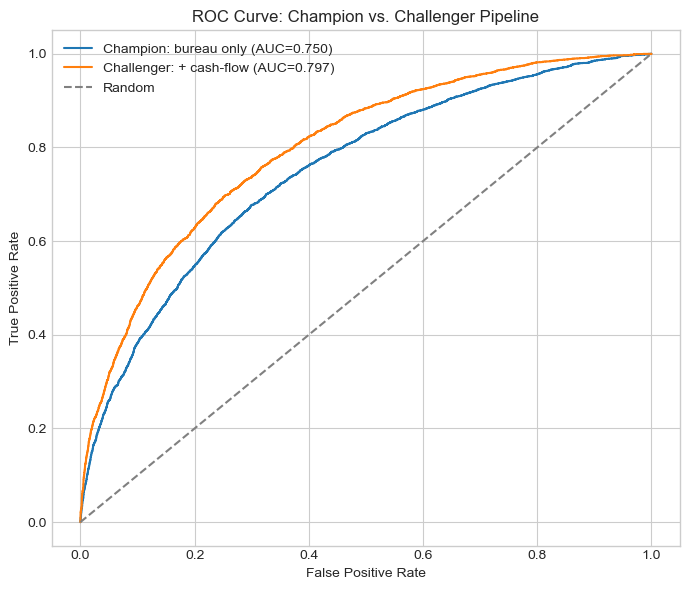

In [25]:
fpr_champ, tpr_champ, _ = roc_curve(y_test, champion_pred)
fpr_chal, tpr_chal, _ = roc_curve(y_test, challenger_pred)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_champ, tpr_champ, label=f"Champion: bureau only (AUC={champion_auc:.3f})")
ax.plot(fpr_chal, tpr_chal, label=f"Challenger: + cash-flow (AUC={challenger_auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: Champion vs. Challenger Pipeline")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/roc_curve.png", dpi=120)
plt.show()

## 7. Feature importance & explainability

Permutation importance — a model-agnostic technique measuring the drop in pipeline
performance when a feature's values are randomly shuffled — works seamlessly here on
the **entire fitted pipeline object** `challenger_pipeline`, not just the bare model. This
correctly accounts for everything happening inside the pipeline (feature engineering,
imputation, encoding) when assessing each raw input column's true contribution.

In [26]:
perm_result = permutation_importance(
    challenger_pipeline, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE,
    scoring="roc_auc", n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

importance_df.head(15)

,feature,importance_mean,importance_std
0,fico_mid,0.157874,0.002281
1,dti,0.009532,0.001324
2,cf_avg_checking_balance,0.008986,0.000691
3,cf_nsf_count_6mo,0.007691,0.000783
4,pay_frequency,0.007592,0.000783
5,cf_overdraft_count_6mo,0.003815,0.000623
6,inq_last_6mths,0.003050,0.000477
7,int_rate,0.003041,0.000611
8,cf_existing_loan_payment_ratio,0.001655,0.000611
9,pub_rec,0.001389,0.000414


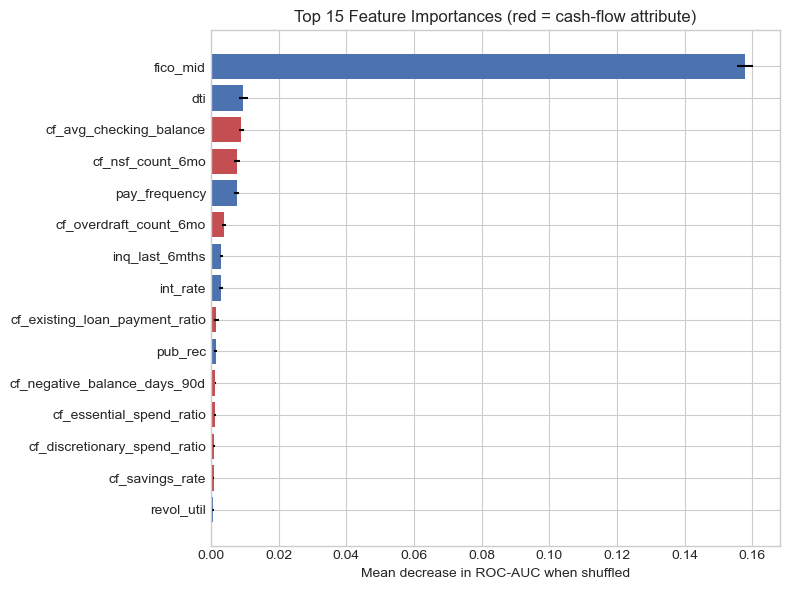

8 of the top 15 features are cash-flow attributes


In [27]:
top_n = 15
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#C44E52" if f.startswith("cf_") else "#4C72B0" for f in top_features["feature"]]
ax.barh(top_features["feature"], top_features["importance_mean"],
        xerr=top_features["importance_std"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Mean decrease in ROC-AUC when shuffled")
ax.set_title(f"Top {top_n} Feature Importances (red = cash-flow attribute)")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=120)
plt.show()

n_cf_in_top = top_features["feature"].str.startswith("cf_").sum()
print(f"{n_cf_in_top} of the top {top_n} features are cash-flow attributes")

In [28]:
import shap

# Run the raw test data through everything EXCEPT the final model step,
# so we get the fully processed (engineered + imputed + encoded) matrix
# that LightGBM actually sees under the hood.
X_test_processed = challenger_pipeline[:-1].transform(X_test)

# Get readable column names for the processed matrix
feature_names_processed = challenger_pipeline.named_steps["preprocessing"].get_feature_names_out()

# Extract just the trained model (the last pipeline step)
model_only = challenger_pipeline.named_steps["model"]

# Build the SHAP explainer for a tree-based model (LightGBM)
explainer = shap.TreeExplainer(model_only)
shap_values = explainer.shap_values(X_test_processed)

/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


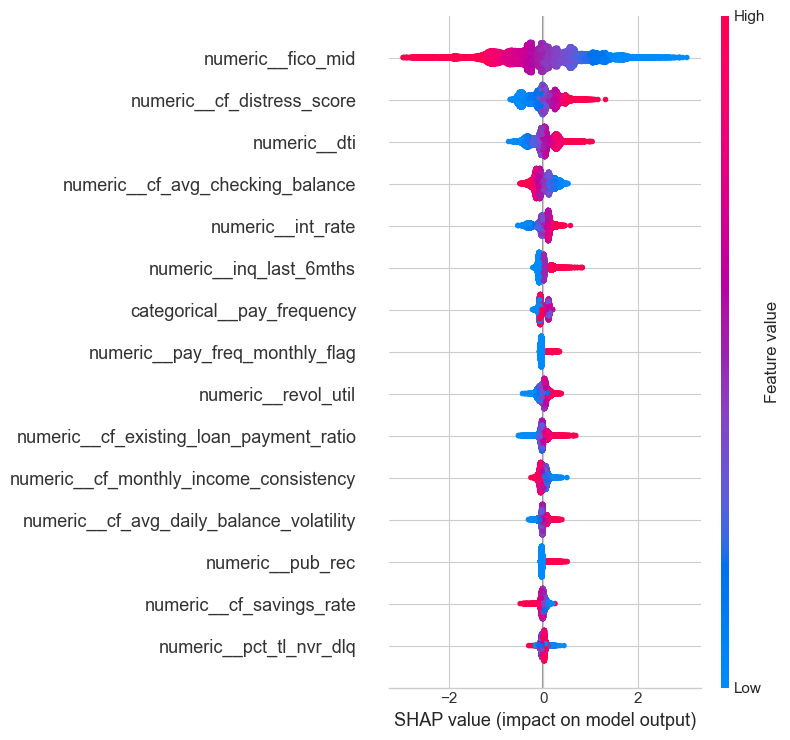

In [29]:
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names_processed, max_display=15, show=False)
plt.tight_layout()
plt.savefig("../outputs/shap_summary.png", dpi=120)
plt.show()

### SHAP vs permutation importance rank features 

Permutation importance measures the drop in overall AUC when a feature is shuffled, while SHAP measures each feature's actual contribution to individual predictions. SHAP is the more rigorous and widely trusted method in credit risk practice, since it explains individual decisions (not just aggregate accuracy) and is less distorted by correlated features. 
fico_mid ranks #1 under both methods, reinforcing it as the dominant, robust risk driver. dti and cf_avg_checking_balance also appear near the top in both, giving extra confidence in those signals. Notably, cf_distress_score ranks #2 under SHAP but doesn't appear in the permutation top 15 at all - likely because it's correlated with cf_nsf_count_6mo and cf_overdraft_count_6mo (which ARE in the permutation list), so shuffling cf_distress_score alone doesn't hurt AUC much since the model can still lean on its correlated siblings. SHAP doesn't have this blind spot, since it attributes credit based on the model's actual internal logic rather than reshuffling.

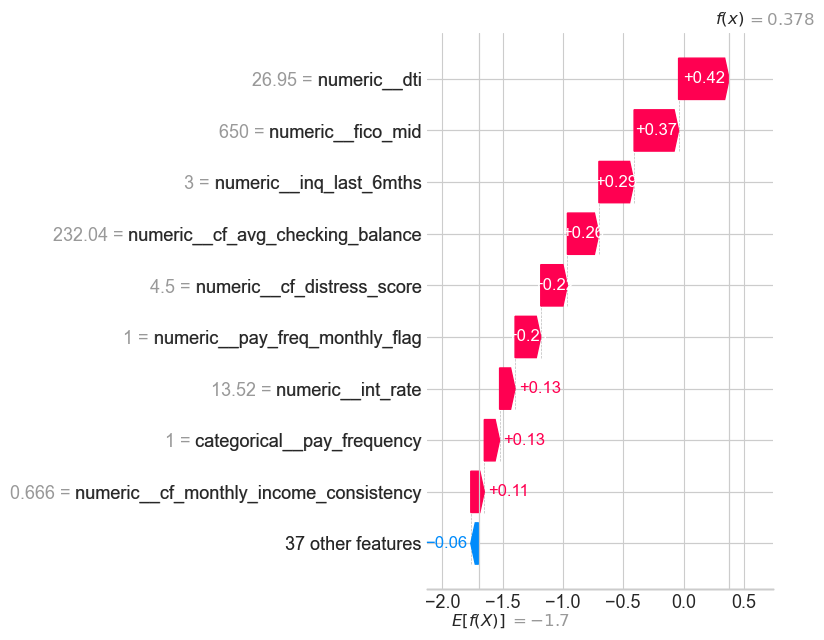

Actual outcome for this loan: Charged Off
Predicted probability: 0.5935


In [30]:
# Pick a specific loan from the test set - e.g., the first one
loan_index = 0

fig = plt.figure(figsize=(10, 5))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[loan_index],
        base_values=explainer.expected_value,
        data=X_test_processed[loan_index] if hasattr(X_test_processed, "__getitem__") else X_test_processed.iloc[loan_index].values,
        feature_names=feature_names_processed,
    ),
    show=False
)
plt.tight_layout()
plt.savefig("../outputs/shap_single_loan.png", dpi=120)
plt.show()

print(f"Actual outcome for this loan: {'Charged Off' if y_test.iloc[loan_index] == 1 else 'Good'}")
print(f"Predicted probability: {challenger_pred[loan_index]:.4f}")

## 8. Model validation: confusion matrix & classification report

In [31]:
cutoff = y_test.mean()
challenger_class = (challenger_pred >= cutoff).astype(int)

cm = confusion_matrix(y_test, challenger_class)
print(f"Confusion matrix at cutoff={cutoff:.3f}:")
print(cm)
print()
print(classification_report(y_test, challenger_class, target_names=["Good", "Charged Off"]))

Confusion matrix at cutoff=0.217:
[[8428 3318]
 [ 904 2350]]

              precision    recall  f1-score   support

        Good       0.90      0.72      0.80     11746
 Charged Off       0.41      0.72      0.53      3254

    accuracy                           0.72     15000
   macro avg       0.66      0.72      0.66     15000
weighted avg       0.80      0.72      0.74     15000



## 9. The pipeline as a single deployable artifact

The real payoff of building this as a proper `Pipeline`: a single object handles raw input
all the way to a prediction. No manual preprocessing required at serving time — this is
exactly how the same code would be deployed in production (e.g., wrapped in an API endpoint
or batch scoring job).

In [32]:
# Score one brand-new application using nothing but the raw columns -
# the pipeline handles feature engineering, imputation, and encoding internally
sample_application = X_test.iloc[[0]]
predicted_default_prob = challenger_pipeline.predict_proba(sample_application)[:, 1][0]

print(f"Raw input columns provided: {sample_application.shape[1]}")
print(f"Predicted default probability: {predicted_default_prob:.4f}")
print(f"Actual outcome: {'Charged Off' if y_test.iloc[0] == 1 else 'Good'}")

Raw input columns provided: 37
Predicted default probability: 0.5935
Actual outcome: Charged Off


In [34]:
champion_gini = results.loc[0, "Gini"]
challenger_gini = results.loc[1, "Gini"]
gini_lift = challenger_gini - champion_gini
n_cf_in_top15 = importance_df.head(15)["feature"].str.startswith("cf_").sum()

summary = f"""
BUSINESS SUMMARY
{'=' * 70}
Adding 15 synthetic cash-flow / alternative-data attributes to a traditional
bureau-only scorecard improved the Gini coefficient from {champion_gini:.3f} to
{challenger_gini:.3f} (a lift of {gini_lift:+.3f}), with {n_cf_in_top15} of the top 15
most predictive features coming from the cash-flow layer.

Both models were built as genuine sklearn.pipeline.Pipeline objects, not ad-hoc
sequential code - feature engineering, imputation, and encoding are pipeline steps,
which means the fitted pipeline can be called directly on a single new raw
application (pipeline.predict_proba(new_app)) with zero manual preprocessing and
zero risk of training/serving skew.

This directly mirrors a real production exercise: evaluating whether a new
alternative data source (e.g., Plaid style cash-flow attributes) justifies
the cost and complexity of integrating it into a live underwriting scorecard, built
the same way it would actually be deployed.
"""
print(summary)


BUSINESS SUMMARY
Adding 15 synthetic cash-flow / alternative-data attributes to a traditional
bureau-only scorecard improved the Gini coefficient from 0.501 to
0.595 (a lift of +0.094), with 8 of the top 15
most predictive features coming from the cash-flow layer.

Both models were built as genuine sklearn.pipeline.Pipeline objects, not ad-hoc
sequential code - feature engineering, imputation, and encoding are pipeline steps,
which means the fitted pipeline can be called directly on a single new raw
application (pipeline.predict_proba(new_app)) with zero manual preprocessing and
zero risk of training/serving skew.

This directly mirrors a real production exercise: evaluating whether a new
alternative data source (e.g., Plaid style cash-flow attributes) justifies
the cost and complexity of integrating it into a live underwriting scorecard, built
the same way it would actually be deployed.

